# Tutorial 02 · Qubit Layout, Couplings, and Sensor Operating Points

In the first tutorial, we defined our quantum dot/sensor system with the capacitance matrices. In this notebook, we start from the **dot and sensor positions**.
The central question is:

> *How does a chosen geometric layout translate into dot-dot couplings, dot-sensor couplings, and sensible sensor operating points?*

The goal is to move step by step from **layout intuition** to **electrostatic couplings** to **readout relevance**.


## Geometry-To-Readout Roadmap

Before going into the details, it helps to keep the full chain in mind:

1. choose a dot and sensor layout
2. compute geometric couplings `Cdd` and `Cds`
3. translate charge states into sensor detuning shifts
4. place those shifts on a Coulomb peak
5. decide which layouts and sensors are promising for readout

```text
Layout
  -> Geometric couplings
  -> State detuning shift
  -> Coulomb peak
  -> Readout sensitivity
```


In [41]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().parent if Path.cwd().name == 'tutorials' else Path.cwd()
sys.path.append(str(repo_root / 'src'))

from readout_simulator import GeometricQuantumDotSystem
import readout_simulator.helper_functions as helper_functions

helper_functions = importlib.reload(helper_functions)
plot_coulomb_peak_minimal = helper_functions.plot_coulomb_peak_minimal
plot_geometry_coupling_summary = helper_functions.plot_geometry_coupling_summary
plot_qubit_layout_variants = helper_functions.plot_qubit_layout_variants

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 125,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#fcfcfe',
})


## 1. Define a Reference Geometry

We first define one concrete multi-dot device.
Here:

- `dot_positions` defines the qubit-dot coordinates
- `sensor_positions` defines the charge sensor coordinates
- `C0`, `alpha`, and `beta` control the strength and spatial decay of the capacitance model

Changing these three ingredients is the main way to explore how layout affects the simulator inputs.



In [42]:
dot_positions = np.array([
    [0.0, 0.0],
    [80.0, 50.0],
    [80.0, -50.0],
    [160.0, 0.0],
])

sensor_positions = np.array([
    [30.0, 100.0],
    [140.0, 100.0],
])

# Couplings (see end of this tutorial)
C0 = 1.0
alpha = 0.70
beta = 0.018

geo_system = GeometricQuantumDotSystem(
    dot_positions=dot_positions,
    sensor_positions=sensor_positions,
    C0=C0,
    alpha=alpha,
    beta=beta,
)

coupling_info = geo_system.get_coupling_info()
print(geo_system)



GeometricQuantumDotSystem:
  Number of dots: 4
  Number of sensors: 2
  Dimensions: 2D
  Base capacitance (C0): 1.00e+00 F
  Coupling strength (α): 0.7
  Distance decay (β): 0.018
  Average dot-dot coupling: 3.33e-01 F
  Average dot-sensor coupling: 9.17e-02 F
  Max coupling strength: 0.238
  Min coupling strength: 0.077


## 2. Layout Summary Figure

This figure combines three pieces of information:

- the physical arrangement of dots and sensors
- the resulting dot-dot capacitance matrix `Cdd`
- the resulting dot-sensor capacitance matrix `Cds`

This is the fastest way to see how a geometric choice becomes an electrostatic model.


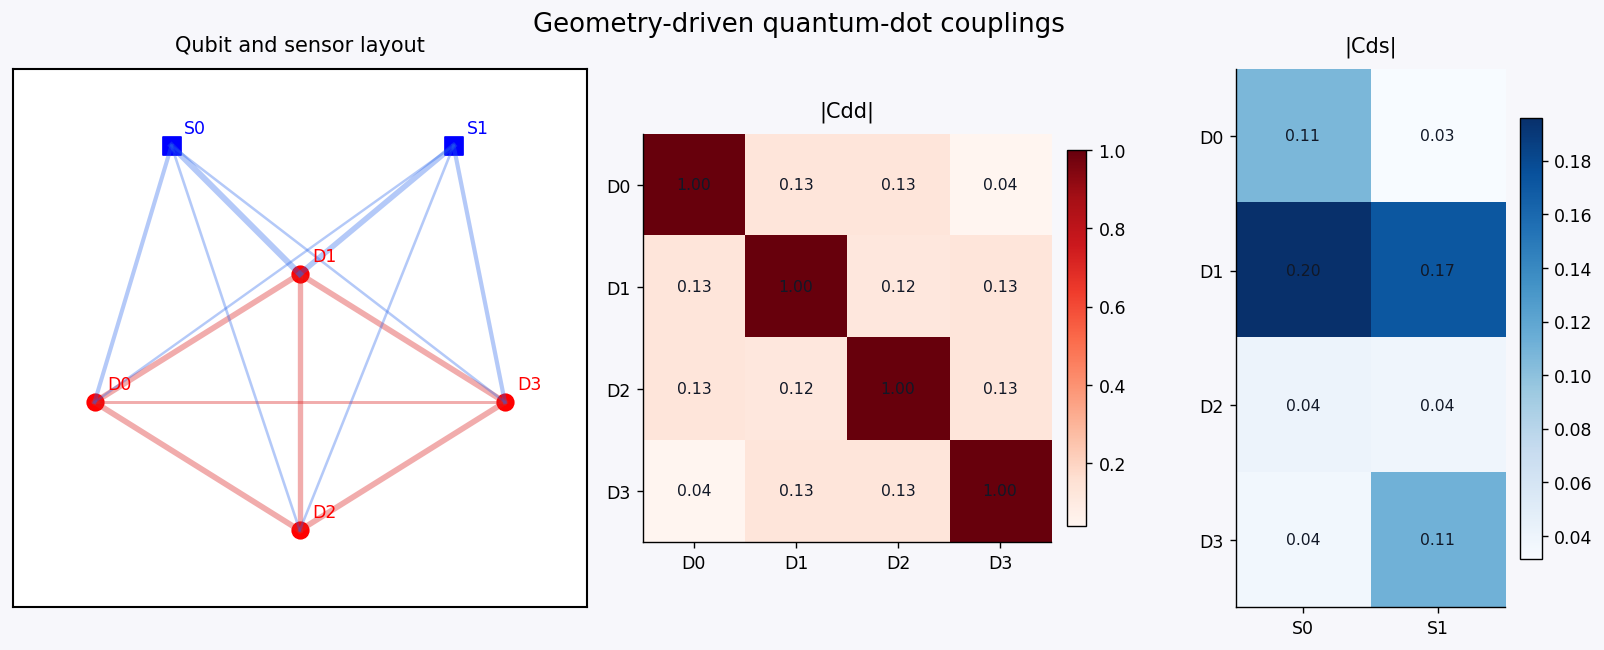

In [43]:
fig, _ = plot_geometry_coupling_summary(
    geo_system,
    figsize=(12.8, 4.9),
    title='Geometry-driven quantum-dot couplings',
)
plt.show()

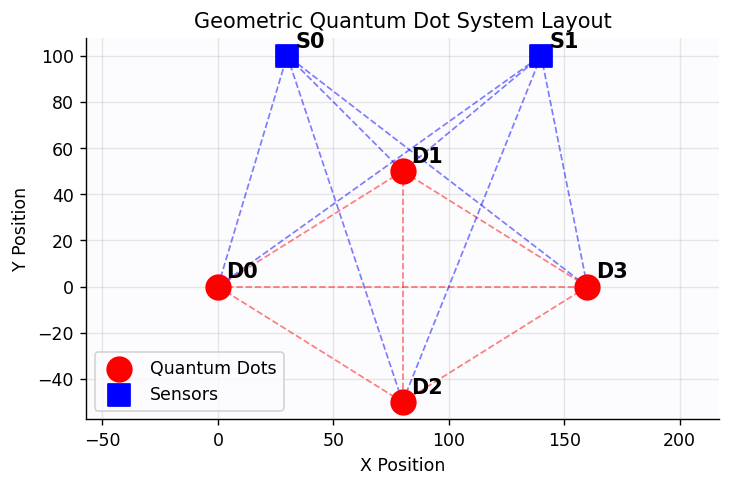

In [44]:
# for quick checks while tuning a device layout
geo_system.plot_system(figsize=(6, 4), show_capacitances=True, capacitance_threshold=0.01)

### What To Notice

- The layout panel shows the physical intuition directly, but the heatmaps make the coupling strengths quantitative
- `Cdd` tells you how strongly dots influence each other; `Cds` tells you how strongly each dot talks to each sensor


## 3. Compare Multiple Geometry Variants

Below we look at three distinct geometry variants, each with 2 sensors and 4 dots:

- a **reference layout** with both sensors above the dot array
- a **top-bottom layout** with one sensor above and one below
- a **rotated dots layout** with different dot positions

This shows how layout choice changes both the visual arrangement and the effective couplings.


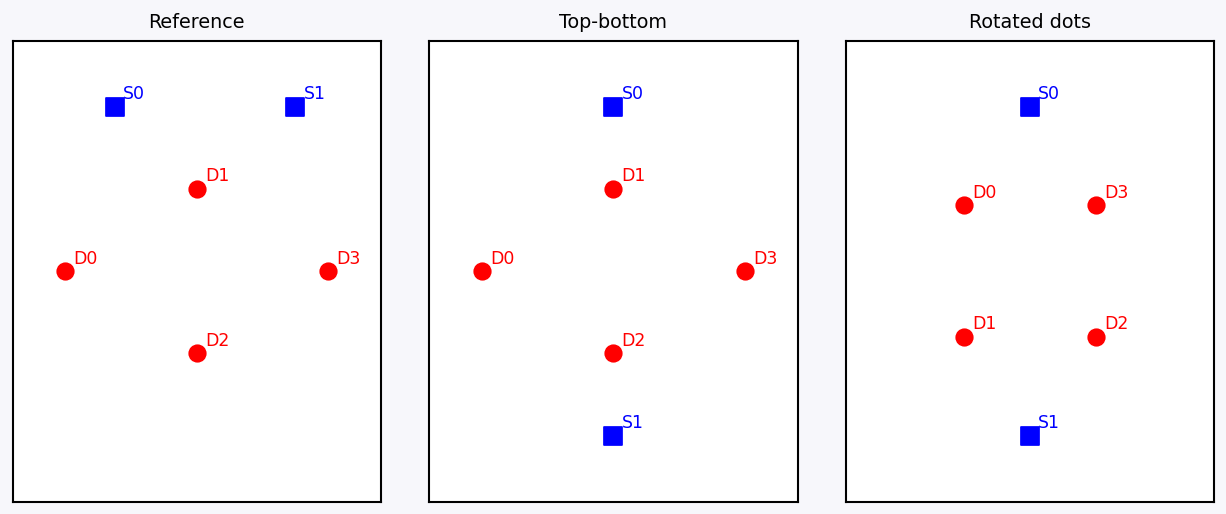

In [45]:
layout_variants = {
    'Reference': {
        'dots': np.array([[0, 0], [80, 50], [80, -50], [160, 0]]),
        'sensors': np.array([[30, 100], [140, 100]]),
    },
    'Top-bottom': {
        'dots': np.array([[0, 0], [80, 50], [80, -50], [160, 0]]),
        'sensors': np.array([[80, 100], [80, -100]]),
    },
    'Rotated dots': {
        'dots': np.array([[40, 40], [40, -40], [120, -40], [120, 40]]),
        'sensors': np.array([[80, 100], [80, -100]]),
    },
}

fig, axes, summary_rows = plot_qubit_layout_variants(
    layout_variants,
    C0=C0,
    alpha=alpha,
    beta=beta,
    figsize=(10, 4),
    figure_title='',
)
plt.show()



### What To Notice
- Keeping the coupling (`C0`, `alpha`, and `beta`) fixed lets you isolate the effect of geometry alone
- Moving one sensor below the device or compressing the dot spacing already changes the coupling pattern noticeably


## 4. Compare How Layout Changes State Sensitivity

Geometry does not only change `Cdd` and `Cds` abstractly.
It also changes how strongly different charge states move each sensor along the Coulomb peak.

To make that concrete, we compare one left-heavy and one right-heavy charge state and ask:

- how large is the induced detuning difference at each sensor?
- which layout creates the strongest readout contrast?


In [46]:
state_left = np.array([1, 0, 1, 0])
state_right = np.array([0, 1, 0, 1])

state_shift_rows = []
for name, layout in layout_variants.items():
    variant = GeometricQuantumDotSystem(
        layout['dots'],
        layout['sensors'],
        C0=C0,
        alpha=alpha,
        beta=beta,
    )
    left_offsets = variant.dot_system.get_energy_offset(state_left, np.zeros(variant.num_sensors), eps0=0.0)
    right_offsets = variant.dot_system.get_energy_offset(state_right, np.zeros(variant.num_sensors), eps0=0.0)
    delta = np.abs(right_offsets - left_offsets)

    state_shift_rows.append((name, delta[0], delta[1]))

print('{:<18} {:>22} {:>22}'.format('Layout', 'Sensor 1 shift (eV)', 'Sensor 2 shift (eV)'))
print('-' * 64)
for name, sensor_1_shift, sensor_2_shift in state_shift_rows:
    print('{:<18} {:>22.3e} {:>22.3e}'.format(name, sensor_1_shift, sensor_2_shift))


Layout                Sensor 1 shift (eV)    Sensor 2 shift (eV)
----------------------------------------------------------------
Reference                       7.159e-02              1.966e-01
Top-bottom                      2.129e-01              2.129e-01
Rotated dots                    0.000e+00              0.000e+00


### Why these shifts differ

The state-induced sensor shift depends on how the chosen charge configuration couples through the geometry-defined matrices. 
- In the *Reference* layout, the two sensors are not equivalent with respect to the left-most and right-most dots, so the two sensors see different shift magnitudes. 
- In the *Top-bottom* layout, the geometry is more symmetric, so both sensors respond with nearly the same contrast. 
- In the *Rotated dots* case, the chosen two states are effectively symmetry-equivalent from the sensors' point of view, so their induced offsets cancel and the reported shift becomes zero.


### What To Notice

- The same pair of charge states can produce quite different sensor shifts in different layouts.
- A good readout layout often gives each sensor a distinct role rather than making both sensors respond identically.


## 5. Map Those State Shifts onto Sensor Conductance Peaks

To read out the charge states for a defined geometry, we pick an operating point on the sensor peak.
The figure below uses two example sensors and projects the state-induced detuning shift onto their conductance curves.

In this section, we use the **Reference** layout defined earlier in the notebook.


This is the bridge between:

- the geometry definition
- the electrostatic model
- the actual conductance contrast the sensor can see


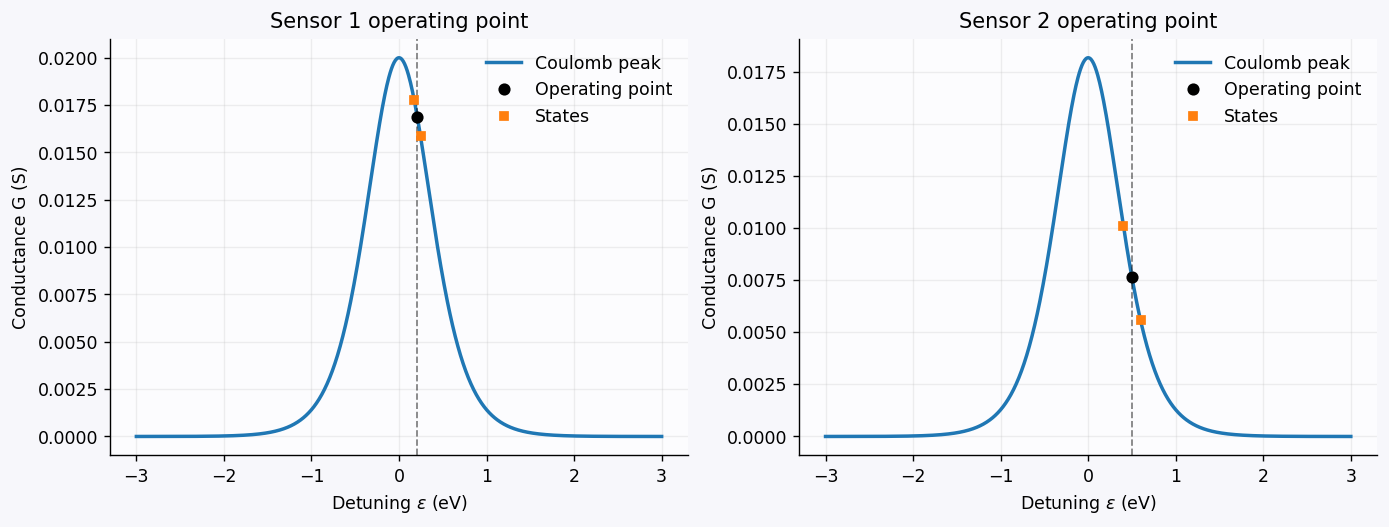

In [53]:
sensor_peak_params = [
    {'g0': 1/50, 'eps0': 0.21, 'eps_width': 1.0},
    {'g0': 1/55, 'eps0': 0.50, 'eps_width': 1.0},
]

left_offsets = geo_system.dot_system.get_energy_offset(state_left, np.zeros(geo_system.num_sensors), eps0=0.0)
right_offsets = geo_system.dot_system.get_energy_offset(state_right, np.zeros(geo_system.num_sensors), eps0=0.0)
delta_offsets = np.abs(right_offsets - left_offsets)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.1), constrained_layout=True)
fig.patch.set_facecolor('#f7f7fb')

for sensor_idx, ax in enumerate(axes):
    plot_coulomb_peak_minimal(
        sensor_peak_params[sensor_idx],
        delta_eps=delta_offsets[sensor_idx],
        ax=ax,
    )
    ax.set_title(f'Sensor {sensor_idx + 1} operating point', fontsize=12)

plt.show()



### What To Notice

- A large state-induced detuning shift does not automatically guarantee a strong conductance contrast $\rightarrow$ the sensor operating point matters too
- The Coulomb peak is where geometry meets measurement: it converts an electrostatic shift into a visible readout change


## 6. Coupling Strength as a Function of Distance

The geometry-based coupling is assumed to decay exponentially with distance:

$C(d) = \alpha  C_0  e^{-\beta d}$

where $C_0$ is the base capacitance scale, $\alpha$ sets the overall coupling strength, $\beta$ sets the spatial decay rate, and $d$ is the distance between the relevant dot and sensor (or between two dots).

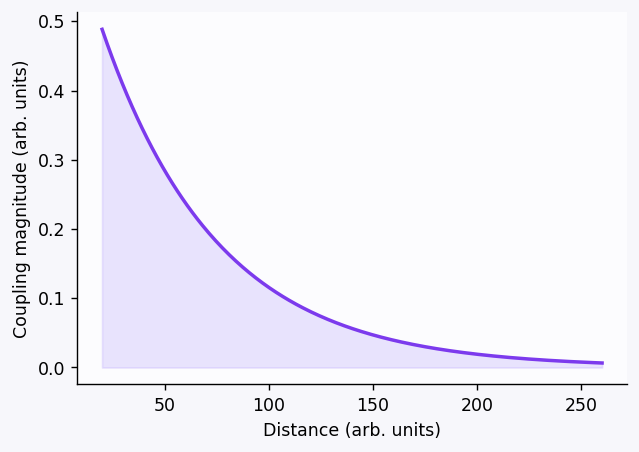

In [57]:
# define the couplings
C0 = 1.0
alpha = 0.70
beta = 0.018

distances = np.linspace(20, 260, 300)
relative_coupling = alpha * C0 * np.exp(-beta * distances)

fig, ax = plt.subplots(figsize=(5, 3.5), constrained_layout=True)
fig.patch.set_facecolor('#f7f7fb')
ax.plot(distances, relative_coupling, color='#7C3AED', lw=2.0)
ax.fill_between(distances, relative_coupling, color='#C4B5FD', alpha=0.35)
ax.set_xlabel('Distance (arb. units)')
ax.set_ylabel('Coupling magnitude (arb. units)')
plt.show()

## Takeaway

- `GeometricQuantumDotSystem` provides a clean route from layout intuition to the simulator's electrostatic inputs
- Comparing several layouts makes it easier to separate *geometry-driven* effects from sensor or noise choices
- State-induced detuning shifts are a compact way to quantify which sensor is most sensitive to a chosen charge rearrangement
- Conductance-peak plots add the next layer by showing how the same geometric shift can become more or less visible depending on the chosen operating point
- The next tutorial adds explicit noise and integrated IQ clustering to build a compact readout dataset
